# Baseline and Pulse Alignment

This notebook studies the best way to align two pulses. A few methods are proposed below:
1. alignment by peak amplitude
2. alignment by trigger threshold
3. alignment by sigma deviation from baseline

In [2]:
import pyradet.h5util.h5reader as h5reader
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# File Structure and Events

In this section
- the directory structure of the HDF5 output is printed on the screen
- arbitrary event is printed on the screen

In [3]:
filedir = 'data/20250319_NaI_4GoKan/'
filename = 'NaI_Background_20250319_195105.hdf5'
reader = h5reader.DataReader( filedir + filename )
reader.Open()

index_offset = -1

In [10]:
adc_attr = reader.GetADCAttributes()

for key,val in adc_attr.items():
    print( "{} : {}".format(key,val), end='\n' )

pre_trigger_window = adc_attr['nb_pre_trigger_sample']
threshold = adc_attr['channel_threshold']

channel = 0
channel_ref = 1

board_address : 839909376
board_buffer_code : 8
board_fw_amc : 419823631
board_fw_roc : 387974160
board_index : 0
board_model : CAEN_V1720
board_run_mode : REGISTER
board_sampling_rate : 250000000.0
channel_DAC : [6550 8864]
channel_enable_mask : 3
channel_index : [0 1]
channel_label : ['NaI-anode' 'NoiseMonitor']
channel_nb_enabled : 2
channel_threshold : [4000 4030]
channel_trigger_loc_enable : [1 0]
channel_trigger_loc_fp_out : [0 0]
channel_tx_threshold : [0 0]
logic_LVDS : 0
logic_TTL : 1
nb_events : 793102
nb_post_trigger_sample : 2248
nb_pre_trigger_sample : 248
nb_samples : 2496
trigger_coin_level : 0
trigger_coin_window : 0
trigger_ext_enable : 0
trigger_fp_ext_out : 0
trigger_fp_loc_out : 0
trigger_fp_sw_out : 0
trigger_loc_enable : 1
trigger_overlap : 0
trigger_polarity : 0
trigger_sw_enable : 0


## Plot an Example Plot

counter : 2
index : 1
option : 0
timestamp : 1742381467
trigger_time_tag : 433385


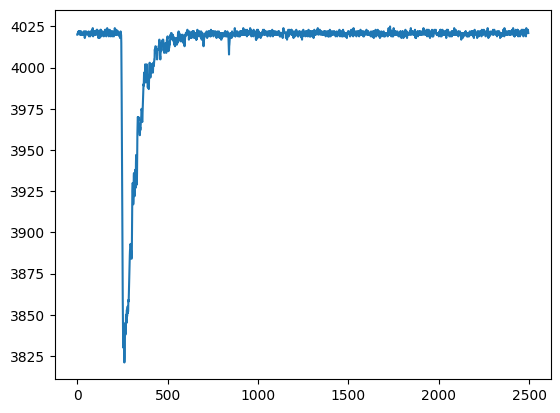

In [7]:
fig = plt.plot()

id = 0

event, event_attr = reader.GetEvent( id )

for key, val in event_attr.items():
    print( key, ':', val )

xdata = 0.004 * np.ones( len(event[channel]) )
plt.plot( event[channel] )
#plt.plot( event[index][:pre_trigger_window] )

- - -
# Pre-Trigger Window Baseline Fluctuation

- Plots the statistical distribution of fluctuation of the pre-trigger baseline
- For events with (very) large baseline fluctuations, the standard deviation and event index is recorded for later inspection

In [8]:
fluctuation = []
    # used to keep track of all standard deviations
event_list = []
    # used to pick out abnormal events

counter = 0
std_threshold = 4

for event_data, event_attr in reader.GetEventIterator():
    
    print( "Processing event {}".format(event_attr["index"]), end='\r' )
    
    tmp = np.std(event_data[channel][:pre_trigger_window-50])
    
    fluctuation.append( tmp )
    
    if tmp > std_threshold:
        event_list.append( (counter, tmp) )

    #if counter > 10000:
    #    break
        
    counter += 1

Processing event 793102

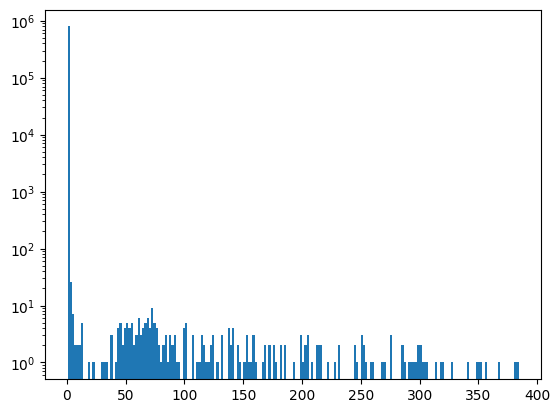

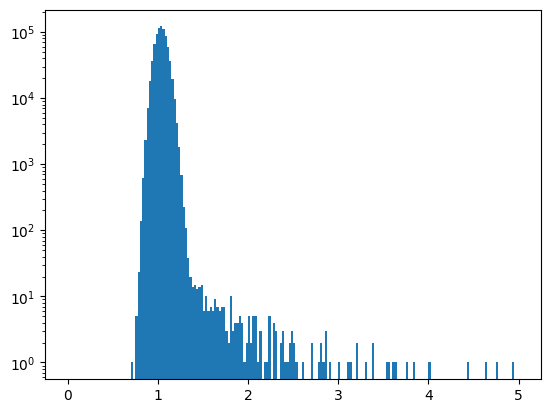

In [9]:
plt.figure()
plt.hist( fluctuation, bins=200 );
plt.yscale('log')

plt.figure()
plt.hist( fluctuation, bins=200, range=[0,5]);
plt.yscale('log')

## Conclusion

Most of the events have baseline standard deviation very small, on the order of 1. Therefore, setting the cutoff at 2 can already reject a lot of 
events.

---
## Pre-Trigger Window Baseline Fluctuation of a Reference Channel
The reference/noise-monitoring channel is left open and not connected to anything

In [11]:
fluctuation2 = []
counter = 0

for event_data, event_attr in reader.GetEventIterator():
    
    print( "Processing event {}".format(event_attr["counter"]), end='\r' )
    counter += 1
    
    fluctuation2.append( np.std(event_data[channel_ref][:pre_trigger_window]) )

Processing event 2752136

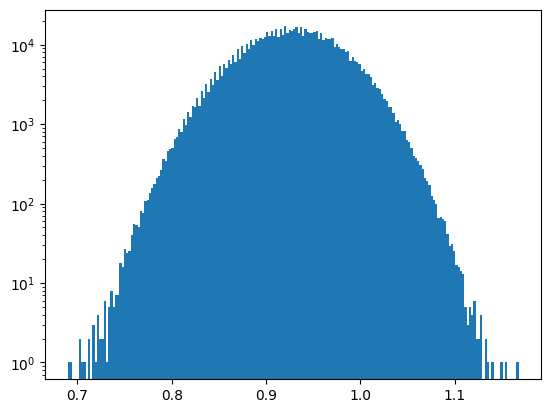

In [12]:
plt.figure()

plt.hist( fluctuation2, bins=200);
plt.yscale('log')

---
## Inspect the Abnormal Events with Large Standard Deviation in the Pre-Trigger Baseline

- it is realized that abnormally high standard deviation is due to pulse preceeding the trigger
- this is due to the pulse arriving within 1 microsecond (pre-trigger window) after the post trigger sample of previous event
    - in this case, the pre-trigger sample of the next event cannot be satisfied
    - the DAQ system will wait until the pulse decays close to the baseline, and when a fluctuation crosses the threshold, data is recorded

counter : 196715
index : 56052
option : 4
timestamp : 1742381613
trigger_time_tag : 1073935201


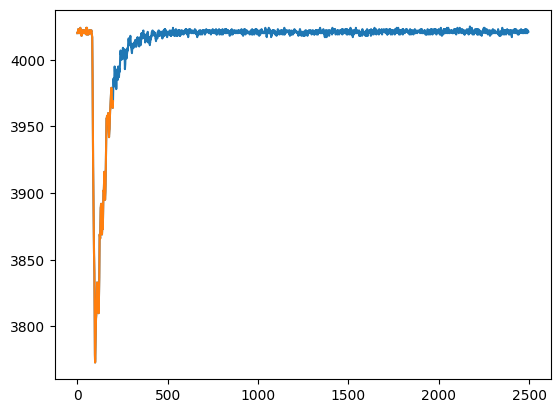

In [16]:
# plot a few problematic events

counter_min = 20
counter_max = 21

for n,(i,j) in enumerate(event_list):

    if n > counter_min and n <= counter_max:
        
        for k,v in event_attr.items():
            print( k, ":", v )
        
        plt.figure()
        event, event_attr = reader.GetEvent( i )
        plt.plot( event[channel] )
        plt.plot( event[channel][:pre_trigger_window-50] )
        plt.show()

        print()
    
    if n >= counter_max:
        break

- - -
## Time Interval Between Two Triggered Events

If above hypothesis is true, then the two pulses should be very close to each other in time. 

In particular, the trigger clock has 8 ns width, and the time separation should be 10 us => 1250 counts
- get statistics of time difference of trigger time tag between abnormal events and preceeding events
- at the same time, use another list to keep track of events that have unusual time separations

In [17]:
plot_list1 = []
    # for very large values
plot_list2 = []
    # for closer values

ttt_list = []

for i,j in event_list:

    event, event_attr = reader.GetEvent( i )
    ttt1 = np.uint64( event_attr['trigger_time_tag'] )
    ettt1 = event_attr['option']
    
    event, event_attr = reader.GetEvent( i-1 )
    ttt2 = np.uint64( event_attr['trigger_time_tag'] )
    ettt2 = event_attr['option']

    delta = ttt1-ttt2
    if ettt1 > ettt2:
        delta = up.uint64(2**32) - delta

    # very large time separation
    if delta > 10000:
        plot_list1.append( i )
    # moderately large time separation
    elif delta > 1400:
        plot_list2.append( i )
        
    ttt_list.append( delta )

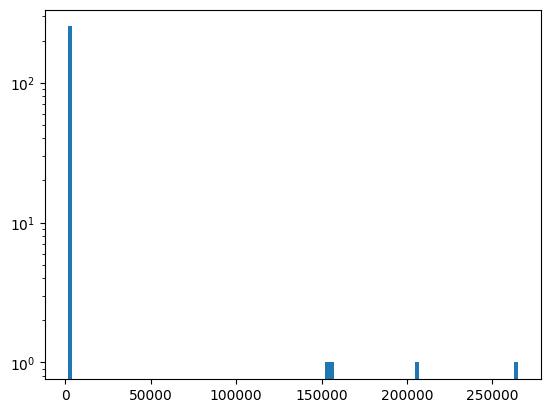

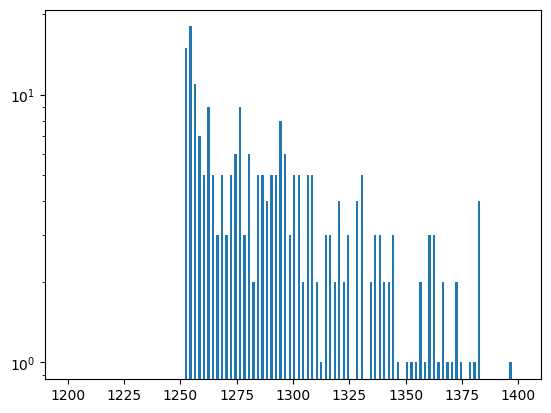

In [18]:
plt.figure()
plt.hist( ttt_list, bins=100);
plt.yscale('log')
plt.show()

plt.figure()
plt.hist( ttt_list, bins=200, range=[1200,1400]);
plt.yscale('log')
plt.show()

- - -
## Check Events with Abnormally Large Time Separation

These events turned out to be those with really large baseline fluctuations, thus there are no temporal correlation (just coincidence)
- probably there is another event preceeding, but since it is too small, it missed the trigger
- the preceeding event made the baseline standard deviation to be larger than usual

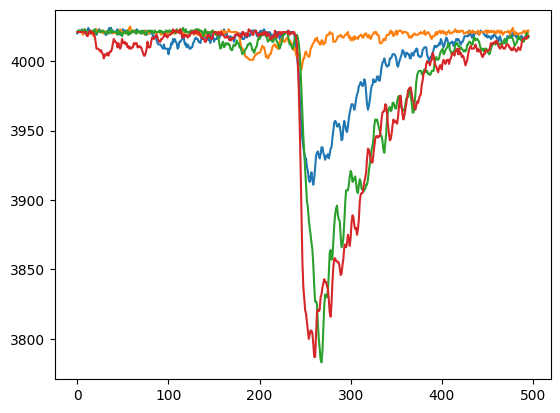

In [19]:
fig = plt.plot()

for id in plot_list1:
    event, event_attr = reader.GetEvent( id )
    plt.plot( event[channel][:2*pre_trigger_window], label = 'event {}'.format(id) )

plt.show()

- - -
## Events with Closer Time Separation
- These events have time separation close to 1250 samples, but not exactly.
- Many of the events are characterized by a pre-existing pulse prior to trigger.
    - **It is possible that the pulse happened while the previous event's acquisition window is just terminated.**

counter : 1259096
index : 361174
option : 27
timestamp : 1742382415
trigger_time_tag : 2546885877
counter : 1259091
index : 361173
option : 27
timestamp : 1742382415
trigger_time_tag : 2546884449


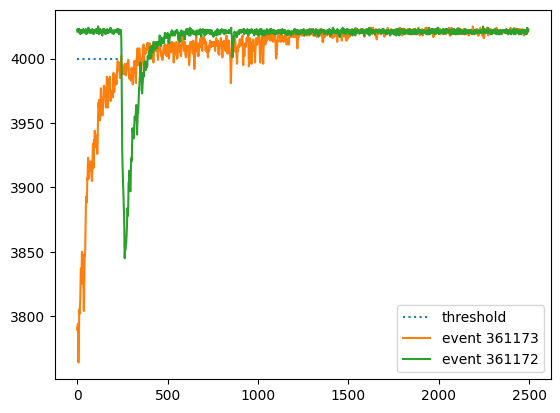

counter : 1883529
index : 541986
option : 41
timestamp : 1742382890
trigger_time_tag : 1842468261
counter : 1883525
index : 541985
option : 41
timestamp : 1742382890
trigger_time_tag : 1842466223


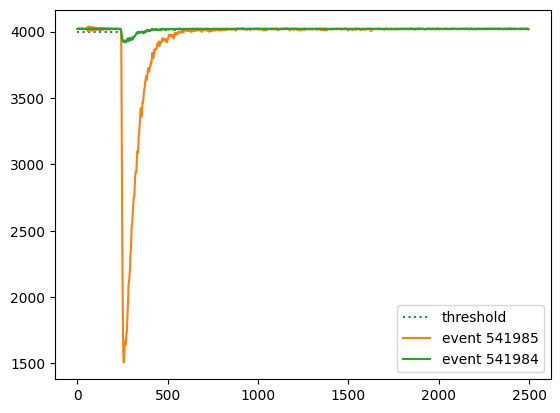

counter : 2250452
index : 648356
option : 49
timestamp : 1742383169
trigger_time_tag : 2293774925
counter : 2250447
index : 648355
option : 49
timestamp : 1742383169
trigger_time_tag : 2293773241


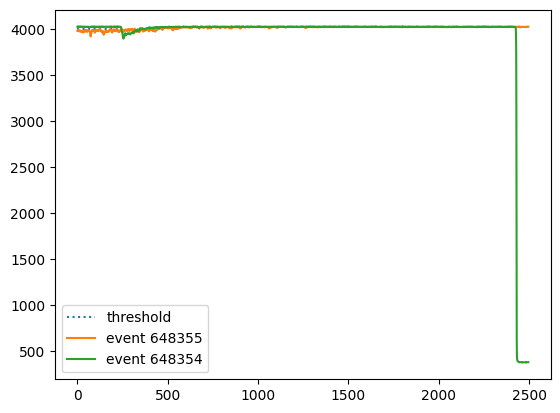

counter : 2655299
index : 765077
option : 58
timestamp : 1742383476
trigger_time_tag : 2057862787
counter : 2655293
index : 765076
option : 58
timestamp : 1742383476
trigger_time_tag : 2057861377


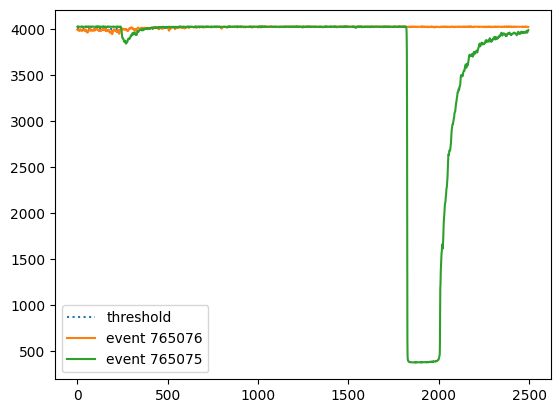

counter : 2675190
index : 770859
option : 58
timestamp : 1742383492
trigger_time_tag : 3961361727
counter : 2675186
index : 770858
option : 58
timestamp : 1742383492
trigger_time_tag : 3961360213


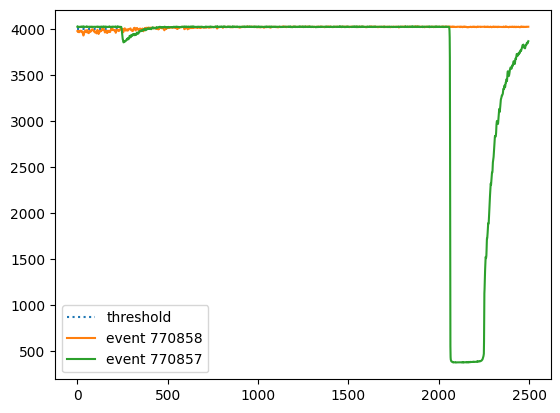

In [21]:
for id in plot_list2:
    
    fig = plt.plot()
    plt.plot( [0,pre_trigger_window], [threshold[channel],threshold[channel]], linestyle = ':', label = 'threshold' )
    
    event, event_attr = reader.GetEvent( id )
    for key, val in event_attr.items():
        print( key, ':', val )
    plt.plot( event[channel], label = 'event {}'.format(id) )

    event, event_attr = reader.GetEvent( id-1 )
    for key, val in event_attr.items():
        print( key, ':', val )
    plt.plot( event[channel], label = 'event {}'.format(id-1) )

    #plt.ylim([3900,4030])
    plt.legend()
    plt.show()

# Optimal Trigger Alignment

A few ways will be used to align pulses. The results will be plotted in the very end.

In [22]:
pre = 20
post = 230

result = {}
result['threshold'] = np.zeros( pre+post )
for i in range(1,10):
    result['{}_sigma'.format(i)] = np.zeros( pre+post )

def GetBaseline( array, pre_trig_window, n = 5 ):
    '''
    Returns the mean and standard deviation of the pre-trigger baseline
    '''
    avg = np.average( array[:pre_trig_window-n] )
    dev = np.std( array[:pre_trig_window-n] )
    return avg, dev
    

def GetPulseBegin( array, pre_trig_window, nSigma ):
    '''
    Returns the beginning of the pulse, aligned by the first deviation from baseline by N sigmas
    np.where() method returns a tuple with the first element being an array of indices that satisties the condition
    '''
    mean, dev = GetBaseline( array, pre_trig_window)
    arr_len = len(array[:pre_trig_window])
    return np.where( np.abs(array[:pre_trig_window]-mean*np.ones(arr_len) ) < nSigma * dev)[0][-1]

counter = 0

std_threshold = 1.5
    # only select events with clean baseline

for event_data, event_attr in reader.GetEventIterator():
    
    print( "Processing event {}".format(event_attr["index"]), end='\r' )

    array_whole = event_data[channel]
    mean, dev = GetBaseline( array_whole, pre_trigger_window )

    if dev > std_threshold:
        continue
        
    array_whole =  mean * np.ones( len(array_whole) ) - array_whole
        # use the entire array to calculate mean and fluctuation

    # partial array used for output
    array_part = array_whole[pre_trigger_window - pre : pre_trigger_window + post]
    
    # the case for simple threshold trigger
    result['threshold'] += array_part / np.max(array_part)

    # alignment based on n-sigma
    for i in range(1,10):
        begin = GetPulseBegin( array_whole, pre_trigger_window, i )
        tmp = array_whole[ begin - pre : begin + post ]
        result['{}_sigma'.format(i)] += tmp/np.max(tmp)
            
    counter += 1

    if counter >= 10000:
        break

for key, val in result.items():
    val /= counter

Processing event 15436

1_sigma 1.8458669176353055
2_sigma 2.2894895225843825
3_sigma 2.5984989792226756
4_sigma 2.6119424998101657
5_sigma 2.5662726789876977
6_sigma 3.1110181227056977
7_sigma 3.4110255282851227
8_sigma 3.787681231671982
9_sigma 3.9573664246119584


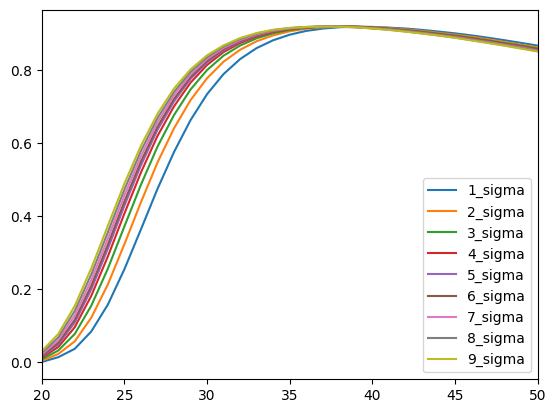

In [23]:
def calculate_rise_time(waveform, timebase):
    """
    Calculate the rise time (10% to 90%) of a monotonically increasing waveform using linear interpolation.

    Parameters:
        waveform (np.array): The waveform data.
        timebase (np.array): Time values corresponding to each waveform point.

    Returns:
        float: Rise time in the same unit as timebase.
    """
    # Determine 10% and 90% levels
    min_val, max_val = waveform[0], waveform[-1]
    ten_percent = min_val + 0.05 * (max_val - min_val)
    ninety_percent = min_val + 0.95 * (max_val - min_val)

    # Find the surrounding points for 10% and 90% crossings
    idx_10 = np.argmax(waveform >= ten_percent)
    idx_90 = np.argmax(waveform >= ninety_percent)

    # Linear interpolation for finer time precision
    t10 = np.interp(ten_percent, waveform[idx_10-1:idx_10+1], timebase[idx_10-1:idx_10+1])
    t90 = np.interp(ninety_percent, waveform[idx_90-1:idx_90+1], timebase[idx_90-1:idx_90+1])

    # Return the refined rise time
    return t90 - t10

plt.figure()

for key, val in result.items():
    if key == 'threshold':
        #plt.plot( np.arange(len(val))+8, val, label = key )
        continue
    else:
        plt.plot( np.arange(len(val)), val, label = key )

    print( key, calculate_rise_time(val, np.arange(len(val) ) ) )

plt.xlim([20,50])
plt.legend()
plt.show()

In [24]:
reader.Close()

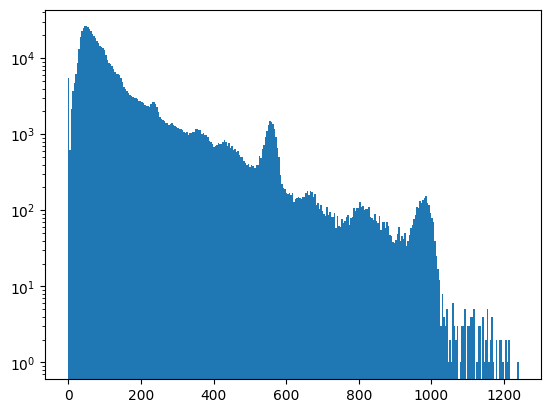

In [263]:
plt.figure()
mask = result[:,1] < 3500
plt.hist( result[:,2][mask], bins=300 );
plt.yscale('log')
plt.show()

In [1]:
plt.figure()
mask = result[:,1] < 3500
plt.hist2d( result[:,1][mask], result[:,2][mask], bins=(100,100), norm=matplotlib.colors.LogNorm())

x1, x2 = [500,3000]
y1, y2 = [80,940]
plt.plot( [x1, x2], [y1, y2], color = 'red' )

x3, x4 = [500,3000]
y3, y4  = [400,1130]
plt.plot( [x3, x4], [y3, y4], color = 'red' )

plt.show()

NameError: name 'plt' is not defined

In [265]:
k = (y2-y1)/(x2-x1)
mask = (result[:,1] < 3000) & (result[:,1] > 500) & (result[:,2] - k * ( result[:,1]-x1) - y1 < 0)
event_list = result[:,0][mask]
print( len(event_list) )

10


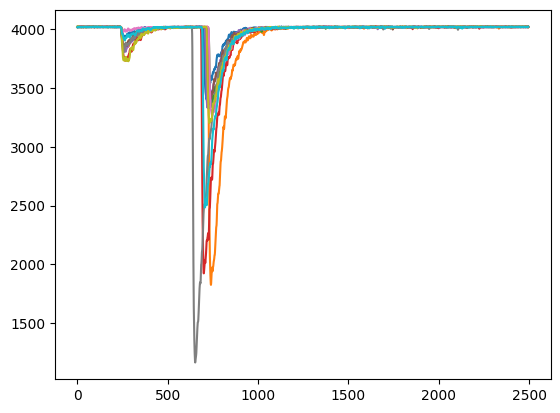

In [266]:
fig = plt.plot()

channel = 0

for id in event_list:

    event, event_attr = reader.GetEvent( int(id) )
    xdata = 0.004 * np.ones( len(event[channel]) )
    plt.plot( event[channel] )

plt.show()

In [267]:
k = (y4-y3)/(x4-x3)
mask = (result[:,1] < 3000) & (result[:,1] > 500) & (result[:,2] - k * (result[:,1]-x3) - y3 > 0)
event_list = result[:,0][mask]

for e in result[mask]:
    print( int(e[0]), e[1], e[2] )

127539 2458.320987654321 1009.4838271604941
138810 1688.4115226337449 783.8999835390949
413055 2150.0205761316874 1003.9353991769549
511250 2159.312757201646 985.7672674897117
525359 1261.7283950617284 788.3555308641975
607303 1558.061728395062 927.0021975308642


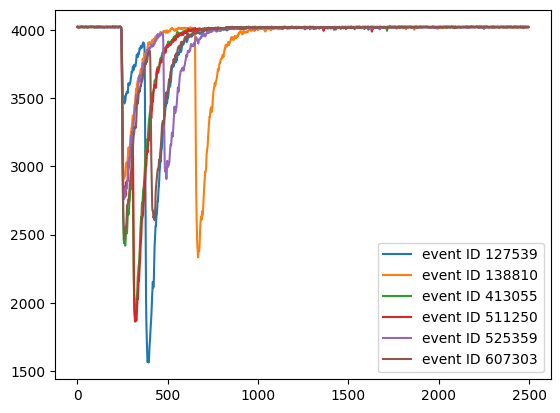

In [269]:
fig = plt.plot()

channel = 0
counter = 0
counter_min = 0
counter_max = 6

for id in event_list:

    if counter >= counter_min:

        event, event_attr = reader.GetEvent( int(id) )
        xdata = 0.004 * np.ones( len(event[channel]) )
        plt.plot( event[channel], label='event ID {}'.format(int(id)) )

    counter += 1
    
    if counter > counter_max:
        break

plt.legend()
plt.show()

In [224]:
print( len(event_list) )

140899
